# 06_backtest_strategies.ipynb - Fases 10-12: Backtest + Validación OOS

**Objetivo**: 
- FASE 10: Backtestear cada estrategia candidata en train (70%)
- FASE 11: Validación out-of-sample (30%)
- FASE 12: Guardar estrategias validadas en data/strategies_library.json

Regla de validación: PF_test >= 0.70 * PF_train

In [9]:
import sys
import json
import re
import pandas as pd
import numpy as np
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT / ".." / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from config.settings import DATA, FEATURES, RISK, BACKTEST
from src.data import load_ohlc_from_yfinance
from src.features import add_all_features
from src.risk import run_backtest_loop, calculate_performance_metrics, find_optimal_coef_sl

import matplotlib.pyplot as plt

print("Imports listos")

Imports listos


## Cargar estrategias candidatas

In [10]:
strategies_path = REPO_ROOT / "data" / "strategies_candidates.json"

with open(strategies_path, "r", encoding="utf-8") as f:
    raw_strategies = json.load(f)

# El archivo guarda reglas como listas de strings; normalizamos a un formato de trabajo
strategies = []
for item in raw_strategies:
    conditions = item.get("conditions", [])
    if isinstance(conditions, list):
        parsed = []
        for cond in conditions:
            if isinstance(cond, str):
                m = re.match(r"^(\w+)\s*(<=|>=|<|>|==)\s*([\d.+-]+)$", cond)
                if m:
                    feature, operator, threshold = m.groups()
                    parsed.append((feature, float(threshold), operator))
                else:
                    parsed.append((cond, None, None))
            else:
                parsed.append(cond)
        strategies.append({"id": item.get("rule_id"), "name": f"Rule {item.get('rule_id')}", "conditions": parsed})
    else:
        strategies.append(item)

print(f"Estrategias cargadas: {len(strategies)}")
print(json.dumps(strategies[:3], indent=2)[:1600])

# Cargar universo de tickers
universe_path = REPO_ROOT / "config" / "tickers_smallcap.txt"
with open(universe_path, "r", encoding="utf-8") as fh:
    tickers = [line.strip() for line in fh if line.strip()]

results = []

for ticker in tickers:
    try:
        df = load_ohlc_from_yfinance(ticker=ticker, period=DATA.period, interval=DATA.interval)
        if df.empty:
            continue

        df = add_all_features(df)
        if "ATR" not in df.columns:
            df["ATR"] = df["ATR_50"]
        df = df.dropna(subset=["ATR", "VWAP_20", "EMA_20", "EMA_50", "SMA_10"]).reset_index(drop=True)
        if df.empty:
            continue

        # Calibración de riesgo usando el método del proyecto
        csl = find_optimal_coef_sl(
            df=df,
            n_samples=RISK.n_samples_csl,
            lookforward_window=RISK.lookforward_window,
            atr_period=FEATURES.atr_period,
            price_min=DATA.price_min,
            price_max=DATA.price_max,
            momentum_k=FEATURES.er_k,
            momentum_threshold=FEATURES.er_threshold,
            admission_range=RISK.csl_admission_range,
            seed=RISK.seed_csl,
        )
        if csl is None:
            continue

        for strategy in strategies:
            conditions = strategy.get("conditions", [])
            if not conditions:
                continue

            signal = pd.Series(True, index=df.index)
            for feature, threshold, operator in conditions:
                if not isinstance(feature, str) or not isinstance(operator, str) or threshold is None:
                    continue
                feature_values = df[feature]
                if operator == "<":
                    signal = signal & (feature_values < threshold)
                elif operator == "<=":
                    signal = signal & (feature_values <= threshold)
                elif operator == ">":
                    signal = signal & (feature_values > threshold)
                elif operator == ">=":
                    signal = signal & (feature_values >= threshold)
                elif operator == "==":
                    signal = signal & (feature_values == threshold)

            if signal.sum() == 0:
                continue

            trades = run_backtest_loop(
                df=df,
                entry_signal=signal,
                c_sl=csl,
                c_tp=None,
                max_bars=BACKTEST.max_bars,
                risk_per_trade=RISK.risk_per_trade,
                capital=BACKTEST.capital,
            )
            metrics = calculate_performance_metrics(trades, BACKTEST.capital)

            results.append({
                "ticker": ticker,
                "strategy_id": strategy.get("id"),
                "strategy_name": strategy.get("name"),
                "conditions": conditions,
                "csl": csl,
                "n_trades": len(trades),
                "trade_pnls": trades["PnL"].tolist() if "PnL" in trades.columns else [],
                "total_pnl": metrics.get("PnL Total", 0),
                "return_pct": metrics.get("Retorno Total (%)", 0),
                "win_rate": metrics.get("Win Rate", 0),
                "profit_factor": metrics.get("Profit Factor", 0),
                "max_drawdown_pct": metrics.get("Max Drawdown (%)", 0),
                "sharpe": metrics.get("Sharpe Ratio", 0),
            })
    except Exception as exc:
        print(f"No se pudo procesar {ticker}: {exc}")

results_df = pd.DataFrame(results)
results_df.head()

Could not get exchangeTimezoneName for ticker '# LISTA INICIAL DE TICKERS SMALL CAP PARA PRUEBA (PRECIO 1-20 USD, VOL > 500K)' reason: 'chart'


Estrategias cargadas: 11
[
  {
    "id": 0,
    "name": "Rule 0",
    "conditions": [
      [
        "VWAP_20",
        2.162,
        "<="
      ],
      [
        "ATR_50",
        0.047,
        "<="
      ],
      [
        "ATR_50",
        0.035,
        "<="
      ],
      [
        "VWAP_20",
        1.355,
        "<="
      ]
    ]
  },
  {
    "id": 1,
    "name": "Rule 1",
    "conditions": [
      [
        "VWAP_20",
        2.162,
        "<="
      ],
      [
        "ATR_50",
        0.047,
        "<="
      ],
      [
        "ATR_50",
        0.035,
        ">"
      ],
      [
        "EMA_20",
        1.294,
        "<="
      ]
    ]
  },
  {
    "id": 2,
    "name": "Rule 2",
    "conditions": [
      [
        "VWAP_20",
        2.162,
        "<="
      ],
      [
        "ATR_50",
        0.047,
        "<="
      ],
      [
        "ATR_50",
        0.035,
        ">"
      ],
      [
        "EMA_20",
        1.294,
        ">"
      ]
    ]
  }
]


$# LISTA INICIAL DE TICKERS SMALL CAP PARA PRUEBA (PRECIO 1-20 USD, VOL > 500K): possibly delisted; no price data found  (period=730d)
Could not get exchangeTimezoneName for ticker '# FORMATO: UNO POR LÍNEA, MAYÚSCULAS, IGNORA LÍNEAS CON #' reason: 'chart'


No se pudo procesar # Lista inicial de tickers small cap para prueba (precio 1-20 USD, vol > 500k): No data found for ticker # Lista inicial de tickers small cap para prueba (precio 1-20 USD, vol > 500k)


$# FORMATO: UNO POR LÍNEA, MAYÚSCULAS, IGNORA LÍNEAS CON #: possibly delisted; no price data found  (period=730d)
Could not get exchangeTimezoneName for ticker '# SMALL CAPS CON LIQUIDEZ DECENTE' reason: 'chart'


No se pudo procesar # Formato: uno por línea, mayúsculas, ignora líneas con #: No data found for ticker # Formato: uno por línea, mayúsculas, ignora líneas con #


$# SMALL CAPS CON LIQUIDEZ DECENTE: possibly delisted; no price data found  (period=730d)


No se pudo procesar # Small caps con liquidez decente: No data found for ticker # Small caps con liquidez decente


,ticker,strategy_id,strategy_name,conditions,csl,n_trades,trade_pnls,total_pnl,return_pct,win_rate,profit_factor,max_drawdown_pct,sharpe
0,ABSI,0,Rule 0,"[(VWAP_20, 2.162, <=), (ATR_50, 0.047, <=), (A...",2.271627,6,"[-99.95409228190546, 149.95003484635356, -99.9...",-100.008602,-1.000086,0.333333,0.749900,-2.984286,-2.050372
1,ABSI,1,Rule 1,"[(VWAP_20, 2.162, <=), (ATR_50, 0.047, <=), (A...",2.271627,7,"[-99.96943362282707, -99.9482173937563, 149.90...",50.027328,0.500273,0.428571,1.125126,-1.009575,0.849324
2,ABSI,2,Rule 2,"[(VWAP_20, 2.162, <=), (ATR_50, 0.047, <=), (A...",2.271627,27,"[-37.84007668495178, 149.9977090671469, 149.84...",-47.993550,-0.479936,0.370370,0.968981,-8.160828,-0.234614
3,ABSI,5,Rule 5,"[(VWAP_20, 2.162, >), (VWAP_20, 4.128, <=), (V...",2.271627,2,"[149.81821716401225, 149.76439793029823]",299.582615,2.995826,1.000000,inf,0.000000,62483.359240
4,ABSI,6,Rule 6,"[(VWAP_20, 2.162, >), (VWAP_20, 4.128, <=), (V...",2.271627,20,"[-99.79677692901328, 149.73618060581768, 149.8...",1046.424635,10.464246,0.650000,2.495844,-2.897055,7.006824


## Visualización de resultados

if not results_df.empty:
    # Gráfico 1: PnL total por estrategia y activo
    plt.figure(figsize=(12, 6))
    for strategy_id, group in results_df.groupby("strategy_id"):
        plt.scatter(group["ticker"], group["return_pct"], label=strategy_id, alpha=0.8)
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Retorno total (%)")
    plt.title("Retorno por estrategia y activo")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # Gráfico 2: PnL acumulado vs trades para cada estrategia y activo
    plt.figure(figsize=(14, 8))
    for _, row in results_df.iterrows():
        pnls = row.get("trade_pnls", [])
        if not pnls:
            continue
        cumulative = np.cumsum(pnls)
        plt.plot(
            range(1, len(cumulative) + 1),
            cumulative,
            label=f"{row['ticker']} | strategy {row['strategy_id']}",
            alpha=0.7,
        )
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.xlabel("Trade #")
    plt.ylabel("PnL acumulado")
    plt.title("PnL acumulado vs trades por estrategia y activo")
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No hay resultados de backtest disponibles.")

# Resumen por estrategia
summary = (
    results_df.groupby("strategy_id")
    .agg(
        activos=("ticker", "nunique"),
        operaciones=("n_trades", "sum"),
        pnl_total=("total_pnl", "sum"),
        retorno_medio=("return_pct", "mean"),
        win_rate_promedio=("win_rate", "mean"),
        profit_factor_promedio=("profit_factor", "mean")
    )
    .sort_values("pnl_total", ascending=False)
)
summary

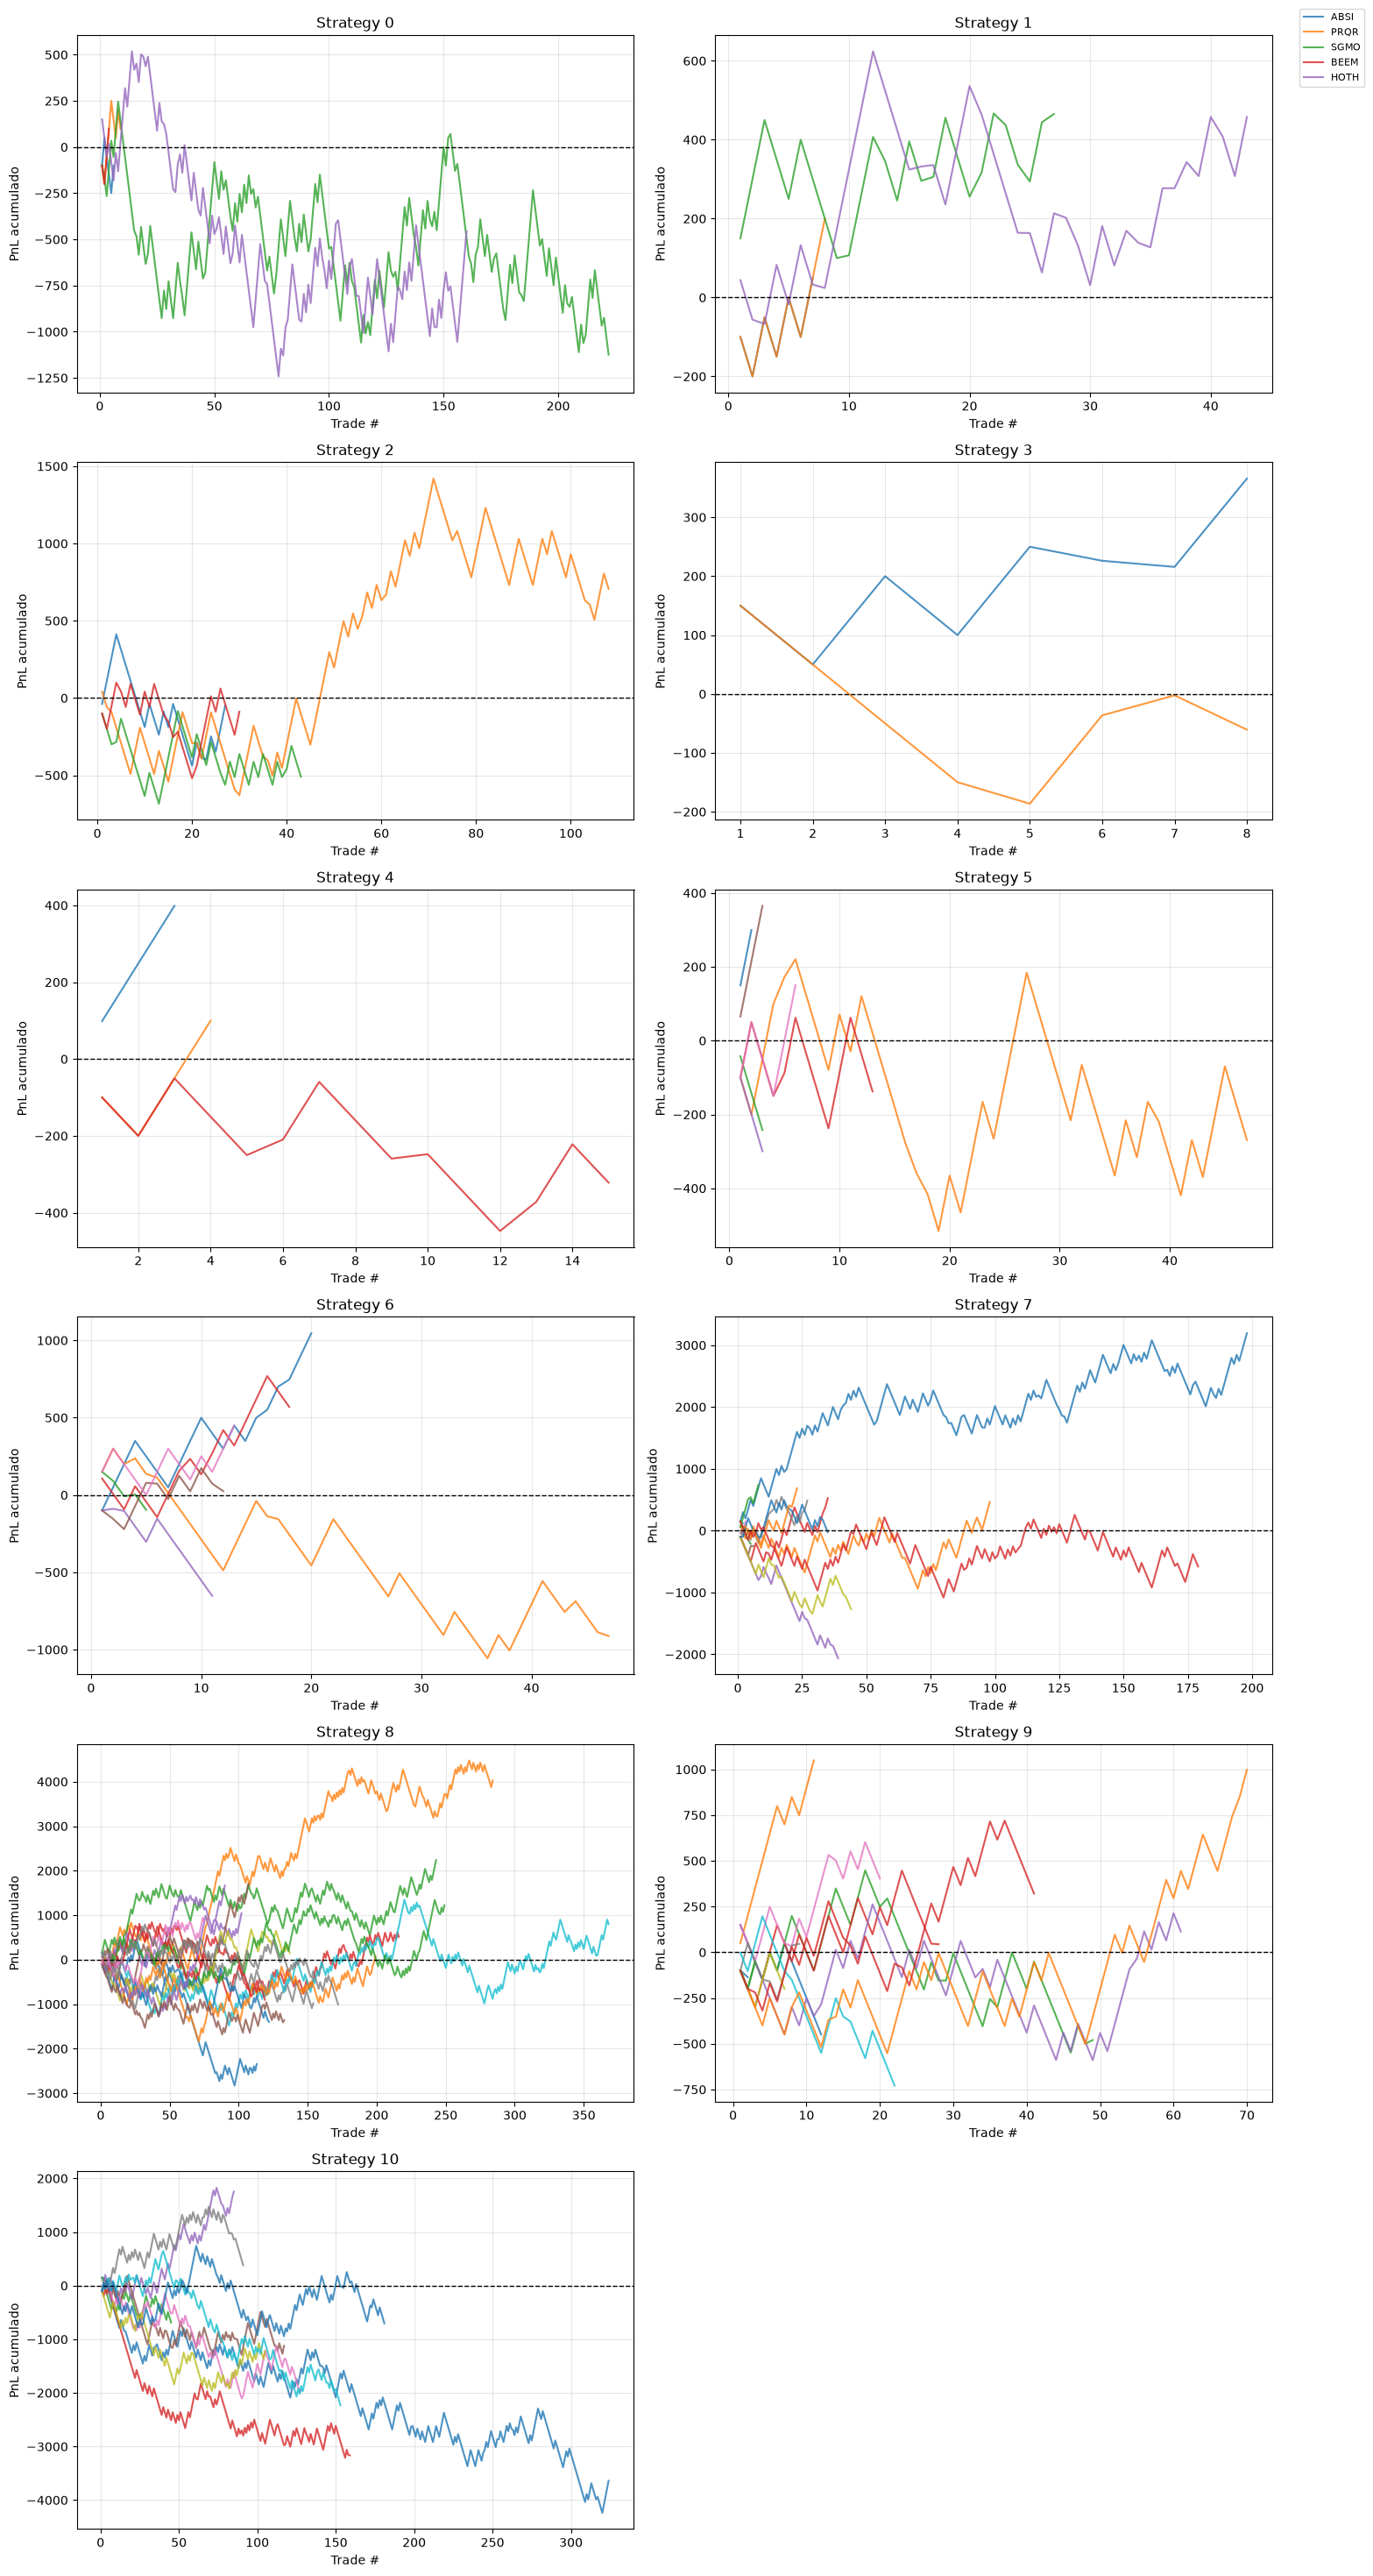

In [11]:
## Dashboard de rendimiento por estrategia y activo

if not results_df.empty:
    strategy_ids = sorted(results_df["strategy_id"].unique().tolist())
    n_strategies = len(strategy_ids)
    n_cols = 2
    n_rows = (n_strategies + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, strategy_id in zip(axes, strategy_ids):
        subset = results_df[results_df["strategy_id"] == strategy_id]
        for _, row in subset.iterrows():
            pnls = row.get("trade_pnls", [])
            if not pnls:
                continue
            cumulative = np.cumsum(pnls)
            ax.plot(range(1, len(cumulative) + 1), cumulative, label=f"{row['ticker']}", alpha=0.8)

        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"Strategy {strategy_id}")
        ax.set_xlabel("Trade #")
        ax.set_ylabel("PnL acumulado")
        ax.grid(alpha=0.3)

    for ax in axes[len(strategy_ids):]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize=8)
    plt.tight_layout(rect=(0, 0, 0.92, 0.98))
    plt.show()
else:
    print("No hay resultados de backtest disponibles para graficar.")

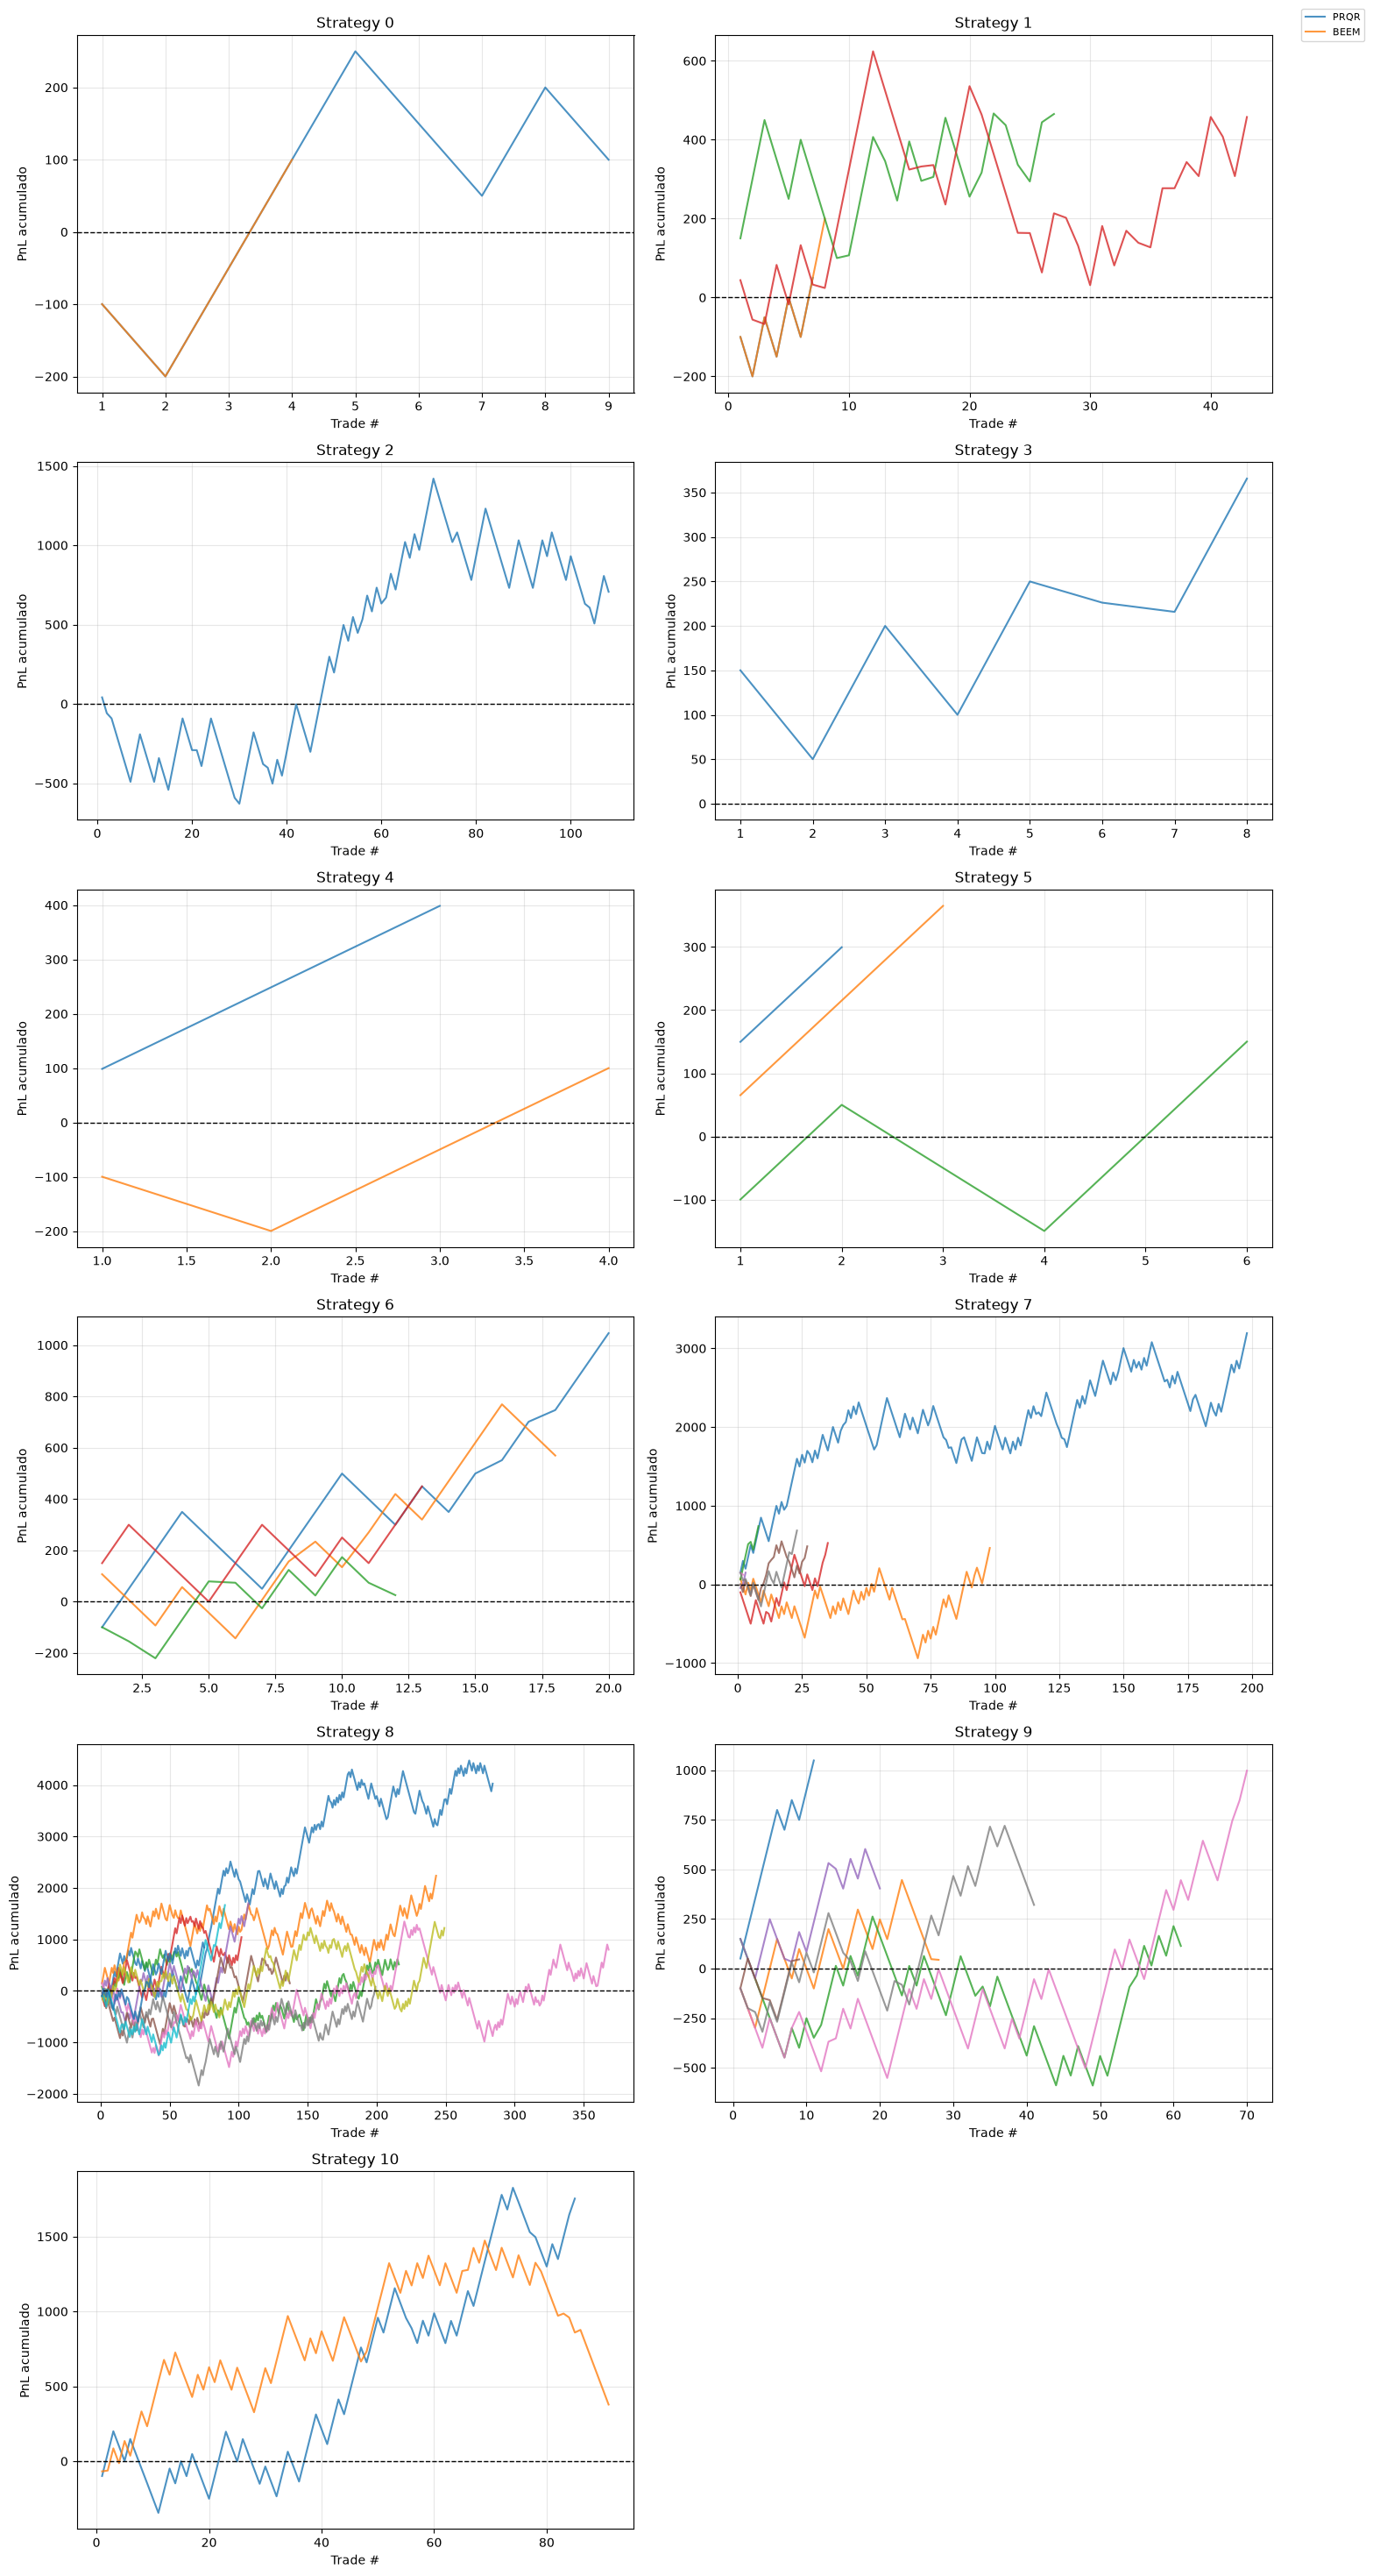

In [12]:
## Dashboard solo con estrategias y activos con PnL total positivo

positive_results = results_df[results_df["total_pnl"] > 0].copy()

if not positive_results.empty:
    strategy_ids = sorted(positive_results["strategy_id"].unique().tolist())
    n_strategies = len(strategy_ids)
    n_cols = 2
    n_rows = max(1, (n_strategies + 1) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, strategy_id in zip(axes, strategy_ids):
        subset = positive_results[positive_results["strategy_id"] == strategy_id]
        for _, row in subset.iterrows():
            pnls = row.get("trade_pnls", [])
            if not pnls:
                continue
            cumulative = np.cumsum(pnls)
            ax.plot(range(1, len(cumulative) + 1), cumulative, label=f"{row['ticker']}", alpha=0.8)

        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"Strategy {strategy_id}")
        ax.set_xlabel("Trade #")
        ax.set_ylabel("PnL acumulado")
        ax.grid(alpha=0.3)

    for ax in axes[len(strategy_ids):]:
        ax.axis("off")

    if len(strategy_ids) > 0:
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize=8)

    plt.tight_layout(rect=(0, 0, 0.92, 0.98))
    plt.show()
else:
    print("No hay resultados con PnL total positivo para graficar.")